In [1]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score

In [2]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=20)

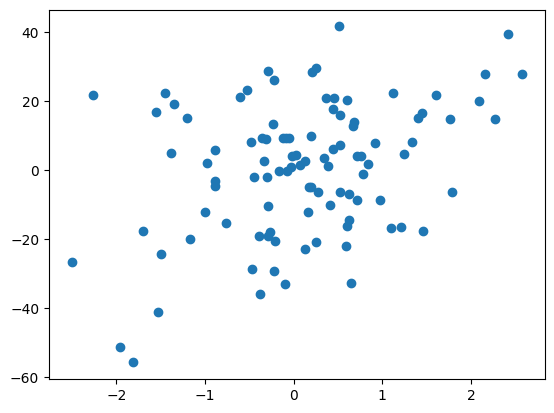

In [3]:
plt.scatter(X,y)

In [15]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=2,test_size=0.2)

In [5]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [6]:
lr.fit(X,y)
print(lr.coef_)
print(lr.intercept_)

[6.71894677]
-0.2650043136548466


In [7]:
np.mean(cross_val_score(lr,X,y,scoring='r2',cv=10))


np.float64(-0.12769155965097467)

In [20]:
y_pred = lr.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.12982143352046804

In [ ]:
class GDRegressor:
    
    def __init__(self,learning_rate,epochs):
        self.m = 100
        self.b = -120
        self.lr = learning_rate
        self.epochs = epochs
        
    def fit(self,X,y):
        # calcualte the b using GD
        for i in range(self.epochs):
            loss_slope_b = -2 * np.sum(y - self.m*X.ravel() - self.b)
            loss_slope_m = -2 * np.sum((y - self.m*X.ravel() - self.b)*X.ravel())
            
            self.b = self.b - (self.lr * loss_slope_b)
            self.m = self.m - (self.lr * loss_slope_m)
        print(self.m,self.b)
        
    def predict(self,X):
        return self.m * X + self.b

In [11]:
gd = GDRegressor(0.001,50)

In [21]:
gd.fit(X_train,y_train)

5.73528682846314 -1.587305823829445


In [13]:
gd.predict(X)

array([[-10.30781326],
       [  0.84143362],
       [ -5.37402697],
       [ -3.83516587],
       [ 17.07953744],
       [ -3.52019074],
       [ -1.04877222],
       [  3.26743366],
       [ -9.53466653],
       [  4.87031117],
       [ -9.32282345],
       [-10.52792195],
       [ -6.22811643],
       [  4.10737006],
       [ 11.6141243 ],
       [  1.03210502],
       [  2.81117819],
       [ 11.77747377],
       [ 15.02916883],
       [-17.10809463],
       [  2.72214376],
       [-13.40348626],
       [ -0.78361814],
       [ -2.1865415 ],
       [-10.71162723],
       [  1.40974539],
       [  4.56242908],
       [ -0.41323267],
       [  3.90860555],
       [ 16.02308899],
       [  1.5788656 ],
       [  8.68081269],
       [ -6.26047665],
       [ -1.40857055],
       [ -6.80840789],
       [  3.24199702],
       [  6.31678165],
       [  0.59082509],
       [ -0.05163447],
       [ -2.17309457],
       [ -0.82501243],
       [ -8.32924376],
       [ -0.64060684],
       [  3

In [22]:
y_pred = gd.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.07882197918730793